
**NOTA DE ESTUDIANTES:**
Hemos recopilado en este notebook todas las funciones que hemos usado para la extracción de audios, embeddings a traves de transfer learning, definicion y uso de decodificador propio, entrenamiento y prueba local.

No es necesario ejecutar este notebook, ya que adjuntamos en la carpeta los modelos con los pesos para que no tenga que hacer TODA la extracción. Es probable que se borren los datos preguardados si se ejecuta, por favor, ejecutar en la otra carpeta en base al ReadMe para que tenga acceso a la interfaz.

Asi mismo, podrá encontrar en las otras carpetas el mismo código que esta en este notebook.

In [ ]:
#librerías y dependencias
import os
import re
import math
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

#para usar gpu si hay
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

WORK_DIR = "."
#crea las carpetas que hemos usado para mayor orden
os.makedirs(f"{WORK_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{WORK_DIR}/embeddings/train", exist_ok=True)
os.makedirs(f"{WORK_DIR}/embeddings/valid", exist_ok=True)
os.makedirs(f"{WORK_DIR}/embeddings/test", exist_ok=True)
os.makedirs(f"{WORK_DIR}/audios/train", exist_ok=True)
os.makedirs(f"{WORK_DIR}/audios/valid", exist_ok=True)
os.makedirs(f"{WORK_DIR}/audios/test", exist_ok=True)


In [ ]:
#Preprocesamiento audio a 16Mhz, para TL de Wav2Vec
def preprocess_audio(filepath, target_sr=16000):
    waveform, sr = torchaudio.load(filepath)
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(sr, target_sr)
        waveform = resampler(waveform)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    wav_1d = waveform.squeeze(0)
    wav_1d = (wav_1d - wav_1d.mean()) / (wav_1d.std() + 1e-5)
    return wav_1d

In [ ]:
#PROCESO TRANSFER LEARNING
#Modelo Wav2Vec

#Parte encoder para el audio, 7 capas 1D
class FeatureEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        conv_layers = [
            (512, 10, 5), (512, 3, 2), (512, 3, 2), (512, 3, 2),
            (512, 3, 2), (512, 2, 2), (512, 2, 2),
        ]
        self.conv_layers = nn.ModuleList()
        in_dim = 1
        for i, (out_dim, kernel, stride) in enumerate(conv_layers):
            layer = nn.ModuleDict({
                "conv": nn.Conv1d(in_dim, out_dim, kernel, stride, bias=False)
            })
            if i == 0:
                layer["layer_norm"] = nn.GroupNorm(out_dim, out_dim)
            self.conv_layers.append(layer)
            in_dim = out_dim

    def forward(self, x):
        x = x.unsqueeze(1)
        for layer in self.conv_layers:
            x = layer["conv"](x)
            if "layer_norm" in layer:
                x = layer["layer_norm"](x)
            x = nn.functional.gelu(x)
        return x.transpose(1, 2)

#Parte positional con normalización de pesos, según el paper
class PositionalConvEmbedding(nn.Module):
    def __init__(self, dim=768, kernel_size=128, groups=16):
        super().__init__()
        self.conv = nn.Conv1d(dim, dim, kernel_size=kernel_size, padding=kernel_size // 2, groups=groups)
        self.conv = nn.utils.parametrizations.weight_norm(self.conv, name="weight", dim=2)
        self.kernel_size = kernel_size

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        if self.kernel_size % 2 == 0:
            x = x[:, :, :-1]
        x = nn.functional.gelu(x)
        return x.transpose(1, 2)


#Encoder del transformer
class TransformerEncoderLayer(nn.Module):
    def __init__(self, dim=768, num_heads=12, ff_dim=3072, dropout=0.1):
        super().__init__()

        self.attention = nn.ModuleDict({
            "q_proj": nn.Linear(dim, dim),
            "k_proj": nn.Linear(dim, dim),
            "v_proj": nn.Linear(dim, dim),
            "out_proj": nn.Linear(dim, dim),
        })

        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.layer_norm = nn.LayerNorm(dim)
        self.feed_forward = nn.ModuleDict({
            "intermediate_dense": nn.Linear(dim, ff_dim),
            "output_dense": nn.Linear(ff_dim, dim),
        })
        self.final_layer_norm = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def _attn(self, x):
        B, T, D = x.shape
        q = self.attention["q_proj"](x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.attention["k_proj"](x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.attention["v_proj"](x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        out = nn.functional.scaled_dot_product_attention(q, k, v)
        out = out.transpose(1, 2).reshape(B, T, D)
        return self.attention["out_proj"](out)

    def forward(self, x):
        residual = x
        x = self._attn(x)
        x = residual + self.dropout(x)
        x = self.layer_norm(x)

        residual = x
        x = self.feed_forward["intermediate_dense"](x)
        x = nn.functional.gelu(x)
        x = self.feed_forward["output_dense"](x)
        x = residual + self.dropout(x)
        x = self.final_layer_norm(x)
        return x

#Unión y uso de solo 6 capas por capacidad y para evitar overfitting, ya que el completo tiene 12
class Wav2Vec2Partial(nn.Module):
    def __init__(self, num_transformer_layers=6, dim=768):
        super().__init__()
        self.feature_extractor = FeatureEncoder()
        self.feature_projection = nn.Linear(512, dim)
        self.pos_conv_embed = PositionalConvEmbedding(dim=dim)
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(dim=dim) for _ in range(num_transformer_layers)
        ])
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.feature_projection(x)
        x = x + self.pos_conv_embed(x)
        for layer in self.layers:
            x = layer(x)
        x = self.layer_norm(x)
        return x

In [ ]:
#Carga de los pesos parciales para el Wav2Vec
#se carga el pt del modelo completo y se guarda un nuevo pt con lo que usaremos.
#carga el modelo original y selecciona solo de 6 capas.

def load_partial_weights(model, checkpoint, num_layers_to_load=6):
    own_state = model.state_dict()
    loaded_keys, skipped_keys = [], []

    for name, param in checkpoint.items():
        mapped_name = None

        if name.startswith("feature_extractor.conv_layers"):
            mapped_name = name

        elif name.startswith("feature_projection.projection"):
            mapped_name = name.replace("feature_projection.projection", "feature_projection")

        elif name.startswith("encoder.pos_conv_embed"):
            mapped_name = name.replace("encoder.pos_conv_embed", "pos_conv_embed")
            mapped_name = mapped_name.replace("conv.weight_g", "conv.parametrizations.weight.original0")
            mapped_name = mapped_name.replace("conv.weight_v", "conv.parametrizations.weight.original1")

        elif name.startswith("encoder.layers"):
            layer_idx = int(name.split(".")[2])
            if layer_idx < num_layers_to_load:
                mapped_name = name.replace("encoder.layers", "layers")

        elif name in ("encoder.layer_norm.weight", "encoder.layer_norm.bias"):
            mapped_name = name.replace("encoder.layer_norm", "layer_norm")

        if mapped_name and mapped_name in own_state and own_state[mapped_name].shape == param.shape:
            own_state[mapped_name].copy_(param)
            loaded_keys.append(mapped_name)
        else:
            skipped_keys.append(name)

    model.load_state_dict(own_state)
    print(f"Cargadas {len(loaded_keys)} claves de {len(checkpoint)} totales en el checkpoint")
    print(f"Claves NO cargadas: {len(skipped_keys)}")
    return model, loaded_keys, skipped_keys

In [ ]:
#CARGA DEL MODELO WAV2VEC PARA EXTRAER LOS PESOS
from transformers import Wav2Vec2Model as _HFWav2Vec2Model

checkpoint_path = f"{WORK_DIR}/checkpoints/wav2vec_small_clean.pt"

_hf_model = _HFWav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
pretrained_weights = _hf_model.state_dict()
torch.save(pretrained_weights, checkpoint_path)
del _hf_model #para que no ocupe memoria

#aqui asignamos el wav2vec con las capas parciales
wav2vec_model = Wav2Vec2Partial(num_transformer_layers=6, dim=768)
checkpoint = torch.load(checkpoint_path, map_location="cpu")
wav2vec_model, loaded_keys, skipped_keys = load_partial_weights(wav2vec_model, checkpoint, num_layers_to_load=6)

for param in wav2vec_model.parameters():
    param.requires_grad = False

wav2vec_model.eval()
wav2vec_model.to(device)


In [ ]:
#EXTRACCION DE EMBEDDINGS CON EL WAV2VEC PARCIAL
#Procesa cada audio a traves del modelo parcial y guarda los embeddings
#que usamos luego.
import shutil

def extract_and_save_embeddings(metadata_df, split_name):

    audio_dir = f"{WORK_DIR}/audios/{split_name}"
    embeddings_dir = f"{WORK_DIR}/embeddings/{split_name}"

    for idx, row in metadata_df.iterrows():
        wav_path = f"{audio_dir}/{row['filename']}"
        emb_path = f"{embeddings_dir}/{row['filename']}.pt"

        if os.path.exists(emb_path):
            continue

        waveform = preprocess_audio(wav_path)
        with torch.no_grad():
            waveform = waveform.unsqueeze(0).to(device)
            #aqui pasa cada audio al wav2vec parcial
            emb = wav2vec_model(waveform).cpu()

        torch.save(emb, emb_path)

#cargamos la metadata ya separada
#Los csv estan con datos limpios, es decir en minusculas, sin signos ni tildes, eso mejoro mucho al desempeño
metadata_train = pd.read_csv(f"{WORK_DIR}/dataset/metadata_train.csv")
metadata_valid = pd.read_csv(f"{WORK_DIR}/dataset/metadata_valid.csv")
metadata_test = pd.read_csv(f"{WORK_DIR}/dataset/metadata_test.csv")

#Proceso de extraccion y guardado de embeddings en carpetas
#Dejamos comentado en caso de que se corra en conjunto, porque los embeddings ya estan extraidos

for split in ["train", "valid", "test"]:
    emb_dir = f"{WORK_DIR}/embeddings/{split}"
    os.makedirs(emb_dir, exist_ok=True)

extract_and_save_embeddings(metadata_train, "train")
extract_and_save_embeddings(metadata_valid, "valid")
extract_and_save_embeddings(metadata_test, "test")

In [ ]:
#DEFINICION DE VOCABULARIO

class Vocabulary:

    def __init__(self):
        self.char2idx = {}
        self.idx2char = {}

    def _clean_sentence(self, sentence: str) -> str:
        sentence = sentence.lower()
        #aqui para controlar el code switching
        sentence = re.sub(r"\[spanish\]", "", sentence)

        sentence = re.sub(r"\[unk\]", "", sentence)
        sentence = re.sub(r"[^\w\s]", "", sentence)
        sentence = re.sub(r"\s+", " ", sentence)
        return sentence.strip()

    #va agregando cada letra que encuentre en un indice unico y forma el vocab
    def build(self, metadata_path):
        df = pd.read_csv(metadata_path)
        df = df.dropna(subset=["transcription"])
        characters = set()
        for sentence in df["transcription"]:
            sentence = str(sentence)
            sentence = self._clean_sentence(sentence)
            if sentence == "":
                continue
            characters.update(sentence)

        self.char2idx = {"<blank>": 0}
        for index, char in enumerate(sorted(characters), start=1):
            self.char2idx[char] = index
        self.idx2char = {idx: char for char, idx in self.char2idx.items()}

    #se usa en la funcion CTC
    def text_to_indices(self, text):
        text = self._clean_sentence(str(text))
        return [self.char2idx[c] for c in text if c in self.char2idx]

    def indices_to_text(self, indices):
        return "".join(
            self.idx2char.get(int(index), "")
            for index in indices
            if int(index) != 0
        )

    def __len__(self):
        return len(self.char2idx)

In [ ]:
#Dataloader de embeddings ya extraidos

class KillKanEmbeddingsDataset(Dataset):

    def __init__(
            self,
            metadata_path,
            embeddings_dir,
            vocabulary: Vocabulary
    ):
        self.embeddings_dir = embeddings_dir
        self.vocabulary = vocabulary

        if isinstance(metadata_path, pd.DataFrame):
            self.data = metadata_path.copy()
        else:
            self.data = pd.read_csv(metadata_path)
        self.data = self.data.dropna(subset=["transcription"])
        self.data.reset_index(drop=True, inplace=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        filename = row["filename"]
        emb_path = os.path.join(self.embeddings_dir, filename + ".pt")

        embedding = torch.load(emb_path).squeeze(0)
        sentence = row["transcription"]
        target = self.vocabulary.text_to_indices(sentence)
        target = torch.tensor(target, dtype=torch.long)

        return embedding, target

In [ ]:
#MODELO IMPLEMENTADO, CONVOLUNCIONAL 1D
#Mejores resultados con GELU ya que es el mismo del wav2vec

class KichwaDecoder1D(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, vocab_size=50, dropout=0.25):  #valores base para el constructor
        super(KichwaDecoder1D, self).__init__()

        self.input_norm = nn.LayerNorm(input_dim)

        self.conv_blocks = nn.Sequential(
            #kernel de 7 para un estimado de 140 ms por cada sílaba
            #padding calculado con el tamaño del kernel y en este caso con el dilation
            #espaciado para más tiempo con el dilation
            nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=7, padding=6, dilation=2),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=7, padding=12, dilation=4),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            #capa para suavizar, sin dilation
            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.input_norm(x)
        x = x.transpose(1, 2)
        x = self.conv_blocks(x)
        x = x.transpose(1, 2)
        logits = self.classifier(x)
        return logits

In [ ]:
#Empaquetado para normalizar audios de distintos tiempos, rellena con ceros los mas cortos
#Para cada batch
#Hace que todos  los vectores tengan el mismo tamaño
def collate_fn(batch):
    embeddings, targets = zip(*batch)
    input_lengths = torch.tensor([len(emb) for emb in embeddings], dtype=torch.long)
    target_lengths = torch.tensor([len(t) for t in targets], dtype=torch.long)
    embeddings_padded = pad_sequence(embeddings, batch_first=True, padding_value=0.0)
    targets_padded = pad_sequence(targets, batch_first=True, padding_value=0)
    return embeddings_padded, targets_padded, input_lengths, target_lengths


In [ ]:
#Decodificador greedy, se ajusta más para las metricas cer y wer
#toma el valor más alto de la pred
def greedy_ctc_decode(logits, vocabulary: Vocabulary):
    pred_ids = logits.argmax(dim=-1).squeeze(0).cpu().tolist()
    decoded_chars = []
    previous_id = None

    for token_id in pred_ids:
        if token_id != previous_id and token_id != 0:
            decoded_chars.append(vocabulary.idx2char.get(token_id, ""))
        previous_id = token_id

    return "".join(decoded_chars)

In [ ]:
#ENTRENAMIENTO DEL DECODER KICHWA
#NO ES NECESARIO EJECUTAR

from jiwer import cer, wer
from tqdm import tqdm

checkpoint_dir = f"{WORK_DIR}/checkpoints"
decoder_save_path = os.path.join(checkpoint_dir, "kichwa_decoder_conv1d.pt")

vocab = Vocabulary()
vocab.build(f"{WORK_DIR}/dataset/metadata_train.csv")
print(f"Vocabulario construido con exito. Tamano total: {len(vocab)} caracteres.")

train_metadata_path = f"{WORK_DIR}/dataset/metadata_train.csv"
valid_metadata_path = f"{WORK_DIR}/dataset/metadata_valid.csv"

#si no hay split de validacion, se hace uno automatico desde el train
if os.path.exists(valid_metadata_path):
    train_source = train_metadata_path
    valid_source = valid_metadata_path
    train_embeddings_dir = f"{WORK_DIR}/embeddings/train"
    valid_embeddings_dir = f"{WORK_DIR}/embeddings/valid"
else:
    print("No se encontro metadata_valid.csv; se hara un split automatico desde metadata_train.csv.")
    frame = pd.read_csv(train_metadata_path)
    valid_frame = frame.sample(frac=0.1, random_state=42)
    train_frame = frame.drop(valid_frame.index).reset_index(drop=True)
    valid_frame = valid_frame.reset_index(drop=True)
    train_source = train_frame
    valid_source = valid_frame
    train_embeddings_dir = f"{WORK_DIR}/embeddings/train"
    valid_embeddings_dir = f"{WORK_DIR}/embeddings/train"

train_dataset = KillKanEmbeddingsDataset(
    metadata_path=train_source,
    embeddings_dir=train_embeddings_dir,
    vocabulary=vocab
)

valid_dataset = KillKanEmbeddingsDataset(
    metadata_path=valid_source,
    embeddings_dir=valid_embeddings_dir,
    vocabulary=vocab
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

modelo_kichwa = KichwaDecoder1D(input_dim=768, hidden_dim=256, vocab_size=len(vocab), dropout=0.25).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.AdamW(modelo_kichwa.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.25, patience=2)

best_val_loss = float("inf")
num_epochs = 50
patience = 4
epochs_no_improve = 0

train_loss_history = []
val_loss_history = []
val_cer_history = []
val_wer_history = []

try:
    for epoch in range(num_epochs):
        modelo_kichwa.train()
        train_loss = 0.0

        progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [train]", leave=True)
        for embeddings, targets, input_lengths, target_lengths in progress:
            embeddings = embeddings.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = modelo_kichwa(embeddings)
            log_probs = logits.log_softmax(2).transpose(0, 1)
            loss = criterion(log_probs, targets, input_lengths, target_lengths)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo_kichwa.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            progress.set_postfix(loss=f"{loss.item():.4f}")

        train_loss /= max(len(train_loader), 1)

        modelo_kichwa.eval()
        val_loss = 0.0
        val_cer = 0.0
        val_wer = 0.0

        with torch.no_grad():
            val_progress = tqdm(valid_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [valid]", leave=False)
            for embeddings, targets, input_lengths, target_lengths in val_progress:
                embeddings = embeddings.to(device)
                targets = targets.to(device)

                logits = modelo_kichwa(embeddings)
                log_probs = logits.log_softmax(2).transpose(0, 1)
                loss = criterion(log_probs, targets, input_lengths, target_lengths)

                val_loss += loss.item()

                batch_cer = 0.0
                batch_wer = 0.0

                for i in range(logits.size(0)):
                    pred_text = greedy_ctc_decode(logits[i].unsqueeze(0), vocab)
                    real_indices = targets[i][:target_lengths[i]].cpu().tolist()
                    real_text = vocab.indices_to_text(real_indices)

                    if len(real_text.strip()) > 0:
                        if len(pred_text.strip()) == 0:
                            batch_cer += 1.0
                            batch_wer += 1.0
                        else:
                            batch_cer += cer(real_text, pred_text)
                            batch_wer += wer(real_text, pred_text)

                val_cer += batch_cer / logits.size(0)
                val_wer += batch_wer / logits.size(0)

                val_progress.set_postfix(loss=f"{loss.item():.4f}")

        val_loss /= max(len(valid_loader), 1)
        val_cer /= max(len(valid_loader), 1)
        val_wer /= max(len(valid_loader), 1)

        scheduler.step(val_loss)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        val_cer_history.append(val_cer)
        val_wer_history.append(val_wer)

        print(f"Epoca [{epoch + 1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | CER: {val_cer:.4f} | WER: {val_wer:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(modelo_kichwa.state_dict(), decoder_save_path)
            print(f"  -> Nuevo mejor modelo guardado (Val Loss: {val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  -> Early stopping en la epoca {epoch + 1}.")
                break

except KeyboardInterrupt:
    print("\nEntrenamiento interrumpido.")

Imagen de la ejecución local del entrenamiento como evidencia.

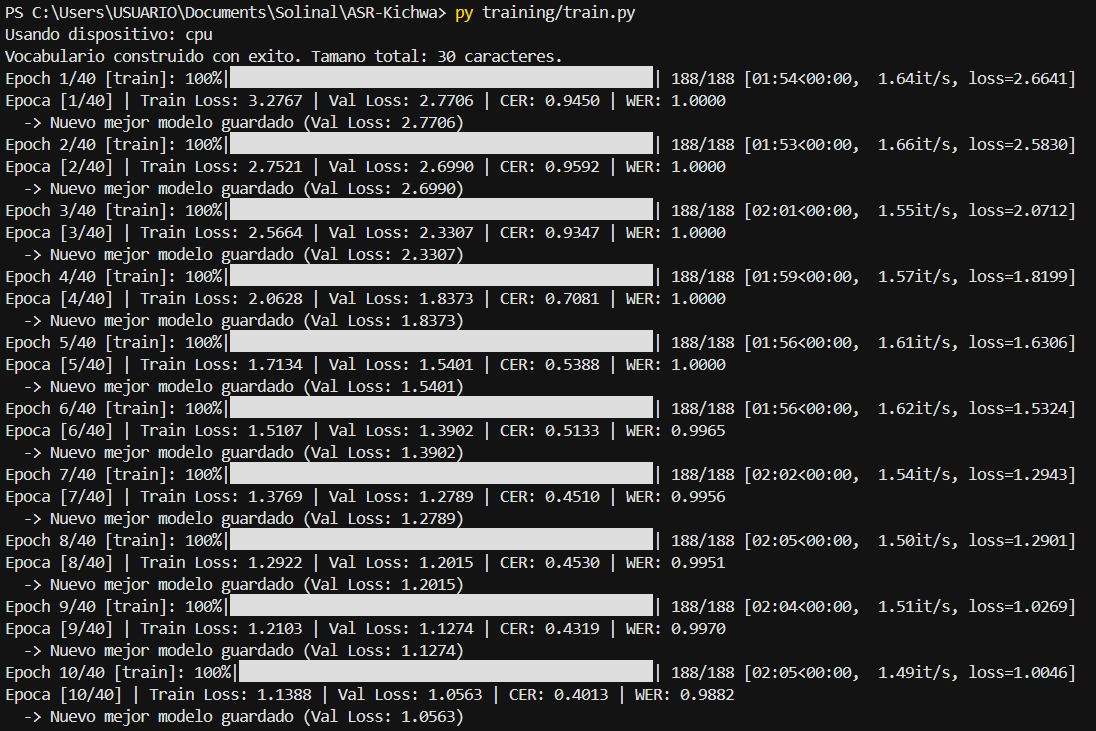

In [ ]:
#CARGA DEL MEJOR MODELO GUARDADO EN CHECKPOINT DEL ASR KICHWA
modelo_kichwa = KichwaDecoder1D(input_dim=768, hidden_dim=256, vocab_size=len(vocab), dropout=0.25).to(device)
modelo_kichwa.load_state_dict(torch.load(decoder_save_path, map_location=device))
modelo_kichwa.eval()